# Лабораторная работа № 2
## *Выявление корреляции между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа*
по курсу Технологии обработки естественного языка  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Коротеева Олеся В.  
**выполнил:** Янкин Иван Ю.  
**группа:** М4121

## импорты

In [1]:
import re
import os
from typing import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

import torch
import torch.nn as nn
import torchmetrics
from torch.utils.data import DataLoader, Dataset

import lightning.pytorch as pl
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, processors
from num2words import num2words
from sklearn.model_selection import train_test_split

pd.set_option('display.max_colwidth', None)

## загрузка и осмотр датасета

In [2]:
import kagglehub

path = kagglehub.dataset_download("maximsuvorov/rutweetcorp")

print("Путь к скачанному датасету:", path)
negative_ds_path = os.path.join(path, 'negative.csv')
positive_ds_path = os.path.join(path, 'positive.csv')

Путь к скачанному датасету: /home/ext-yankin@ad.speechpro.com/.cache/kagglehub/datasets/maximsuvorov/rutweetcorp/versions/3


In [3]:
df1 = pd.read_csv(negative_ds_path)
df2 = pd.read_csv(positive_ds_path)

df = pd.concat([df1, df2], ignore_index=True)
df['label'] = df.ttype.replace(-1, 0)
df.head(1)

,id,tdate,tname,ttext,ttype,trep,trtw,tfav,tstcount,tfoll,tfrien,listcount,label
0,408906762813579264,1386325944,dugarchikbellko,"на работе был полный пиддес :| и так каждое закрытие месяца, я же свихнусь так D:",-1,0,0,0,8064,111,94,2,0


## предобработка текста
- замена чисел, унификация смеха, обработка смешанных слов ('5-го');
- `вход -> выход:` `(text_column : Series[str]) -> (text_column_prepared : Series[object])`

In [4]:
RE_SUFFIX = re.compile(r'\b(\d+)-[а-яё]+\b')
RE_MIXED = re.compile(r'\b\d+[а-яё]+\b')
RE_NUMBER = re.compile(r'\b\d+(?:\.\d+)?')

RE_LAUGH = re.compile(r'\b[авих]{2,}\b')
RE_RT = re.compile(r'\brt\b', re.IGNORECASE)

RE_URL = re.compile(r'https?://\S+|www\.\S+')
RE_USER = re.compile(r'@\w+:')
RE_USER_v2 = re.compile(r'@\w+')
RE_HASHTAG = re.compile(r'#')
RE_CLEAN_CHAR = re.compile(r'[^а-яёa-z0-9\s.!?,:\-().....–—«»“”]+', re.IGNORECASE)

def text2num(match):
    val = match.group()
    if len(val) > 15: 
        return val
    try:
        return num2words(val, lang='ru')
    except (ValueError, TypeError):
        return val

def split_mixed_numchar(match):
    """
    '22кг' -> 'двадцать два кг'
    """
    word = match.group()
    num = "".join(c for c in word if c.isdigit())
    txt = "".join(c for c in word if c.isalpha())
    return f"{num2words(num, lang='ru')} {txt}".strip()

def clean_patterns(text):
    text = text.lower()
    text = RE_URL.sub('', text)
    text = RE_USER.sub('', text)
    text = RE_USER_v2.sub('', text)
    text = RE_RT.sub('', text)
    text = RE_HASHTAG.sub('', text)

    text = RE_SUFFIX.sub(r'\1', text)
    text = RE_MIXED.sub(split_mixed_numchar, text)
    text = RE_NUMBER.sub(text2num, text)
    text = RE_LAUGH.sub("хах", text)

    text = RE_CLEAN_CHAR.sub(' ', text)
    
    text = re.sub(r'\s+', ' ', text)
    return text

def prepare(text):
    if not isinstance(text, str): 
        return ""
    text = clean_patterns(text)
    text = text.replace('…', '').replace('–', '-')
    text = text.lower().replace('ё', 'е')
    return text.strip()

In [5]:
text_column = df.ttext
text_column_prepared = text_column.progress_apply(prepare)
text_column_prepared.head(3)

100%|██████████| 226834/226834 [00:07<00:00, 28455.90it/s]


0    на работе был полный пиддес : и так каждое закрытие месяца, я же свихнусь так d:
1          коллеги сидят рубятся в urban terror, а я из-за долбанной винды не могу :(
2                                            как говорят обещаного три года ждут...((
Name: ttext, dtype: object

In [6]:
text_column_prepared.sample(3)

148011                        одноклассница реп про меня сочинила)))))))))
69770     срочно !!! фоторобот лиц подозреваемых в теракте в волгограде ((
127537                      хах он думает я звизда пападу в каадр!один! :d
Name: ttext, dtype: object

## создание DataModule
- с помощью `pl.LightningDataModule`.

In [7]:
class RuTweetDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int]):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {"text": self.texts[idx], "label": self.labels[idx]}

In [8]:
class RuTweetDataModule(pl.LightningDataModule):
    def __init__(
        self,
        texts: pd.Series,
        labels: pd.Series,
        vocab_size: int = 5000,
        batch_size: int = 64,
        tokenizer_type: str = 'bpe',
        max_length: int = 128,
        num_workers: int = 4
    ):
        super().__init__()
        self.save_hyperparameters(ignore=['texts', 'labels'])
        
        self.all_texts = texts
        self.all_labels = labels
        special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
        
        if tokenizer_type not in ['bpe', 'wordpiece', 'unigram']:
            raise TypeError('Use bpe, unigram or wordpiece tokenizer_type')
        elif tokenizer_type == 'bpe':
            self.tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
            self.trainer_tokenizer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=special_tokens)
        elif tokenizer_type == 'wordpiece':
            self.tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
            self.trainer_tokenizer = trainers.WordPieceTrainer(vocab_size=vocab_size, special_tokens=special_tokens)
        elif tokenizer_type == 'unigram':
            self.tokenizer = Tokenizer(models.Unigram())
            self.trainer_tokenizer = trainers.UnigramTrainer(vocab_size=vocab_size, special_tokens=special_tokens)
        
        self.tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    def prepare_data(self):
        def get_training_corpus():
            for i in range(0, len(self.all_texts), 1000):
                yield self.all_texts.iloc[i : i + 1000].astype(str).tolist()

        self.tokenizer.train_from_iterator(get_training_corpus(), trainer=self.trainer_tokenizer)
        
        self.tokenizer.post_processor = processors.TemplateProcessing(
            single="[CLS] $A [SEP]",
            special_tokens=[
                ("[CLS]", self.tokenizer.token_to_id("[CLS]")),
                ("[SEP]", self.tokenizer.token_to_id("[SEP]")),
            ],
        )
        
        self.tokenizer.enable_truncation(max_length=self.hparams.max_length)
        self.tokenizer.enable_padding(pad_id=self.tokenizer.token_to_id("[PAD]"), pad_token="[PAD]")

    def setup(self, stage: Optional[str] = None):
        train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
            self.all_texts, 
            self.all_labels, 
            test_size=0.1, 
            stratify=self.all_labels, 
            random_state=42
        )

        if stage == "fit":
            train_texts, val_texts, train_labels, val_labels = train_test_split(
                train_val_texts, 
                train_val_labels, 
                test_size=0.1, 
                stratify=train_val_labels, 
                random_state=42
            )
            
            self.train_ds = RuTweetDataset(train_texts.tolist(), train_labels.tolist())
            self.val_ds = RuTweetDataset(val_texts.tolist(), val_labels.tolist())

        if stage == "test":
            self.test_ds = RuTweetDataset(test_texts.tolist(), test_labels.tolist())

    def collate_fn(self, batch) -> Dict[str, torch.Tensor]:
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
        
        encoded = self.tokenizer.encode_batch(texts)
        input_ids = torch.tensor([e.ids for e in encoded])
        attention_mask = torch.tensor([e.attention_mask for e in encoded])
        
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.hparams.batch_size, 
                          shuffle=True, collate_fn=self.collate_fn, num_workers=self.hparams.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.hparams.batch_size, 
                          collate_fn=self.collate_fn, num_workers=self.hparams.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.hparams.batch_size, 
                          collate_fn=self.collate_fn, num_workers=self.hparams.num_workers)

## создание Model
- с помощью `pl.LightningModule`.

In [9]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size=1):
        super().__init__()
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embd_size, padding_idx=0)
        self.dropout = nn.Dropout(0.3)

        self.rnn = nn.LSTM(
            embd_size, 
            hidden_size, 
            batch_first=True, 
            bidirectional=True,
            num_layers=1
        )
        
        self.fc = nn.Linear(hidden_size * 2, output_size)
        self.criterion = nn.BCEWithLogitsLoss()
        self.metrics = nn.ModuleDict({
            f"{split}_f1": torchmetrics.F1Score(task="binary") 
            for split in ["train", "val", "test"]
        })

    def forward(self, x):
        # x: [batch_size, seq_len]
        x = self.dropout(self.embedding(x)) # [batch_size, seq_len, embd_size]
        
        output, (hn, cn) = self.rnn(x)
        
        # hn: [num_layers * num_directions, batch, hidden_size]
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1) # [batch, hidden*2]
        
        return self.fc(last_hidden)

    def _shared_step(self, batch, split):
        x, y = batch["input_ids"], batch["labels"]
        logits = self(x).squeeze(1)
        
        loss = self.criterion(logits, y.float())
        
        preds = torch.sigmoid(logits)
        metric_key = f"{split}_f1"
        self.metrics[metric_key](preds, y)
        
        self.log(f"{split}_loss", loss, on_step=(split == "train"), on_epoch=True, prog_bar=True)
        self.log(f"{split}_f1", self.metrics[metric_key], on_step=False, on_epoch=True, prog_bar=True)
        
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, "test")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

## создание Trainer
- с помощью `pl.Trainer`.

In [ ]:
vocab_sizes = [1000, 3000, 4000, 5000, 7000, 9000, 12000, 15000, 20000, 30000, 40000]
tokenizer_types = ['bpe', 'unigram', 'wordpiece']
all_results = {t: [] for t in tokenizer_types}

for t_type in tokenizer_types:
    print(f"Токенизатор: {t_type}")
    for vsize in vocab_sizes:
        dm = RuTweetDataModule(
            texts=text_column_prepared, 
            labels=df.label, 
            vocab_size=vsize, 
            max_length=256,
            batch_size=512,
            tokenizer_type=t_type
        )
        dm.prepare_data()
        actual_vsize = dm.tokenizer.get_vocab_size() 

        model = RNNModel(
            vocab_size=actual_vsize, 
            embd_size=256, 
            hidden_size=256, 
            output_size=1
        )
        
        trainer = pl.Trainer(
            max_epochs=5,
            enable_checkpointing=True,
            logger=True
        )
        
        trainer.fit(model, datamodule=dm)
        test_metrics = trainer.test(model, datamodule=dm, ckpt_path="best")
        
        f1_value = test_metrics[0]['test_f1']
        all_results[t_type].append(f1_value)
        print(f"Результат для {t_type}_{vsize}: F1 = {f1_value:.4f}")

        import gc
        del dm, model, trainer
        gc.collect()
        torch.cuda.empty_cache()

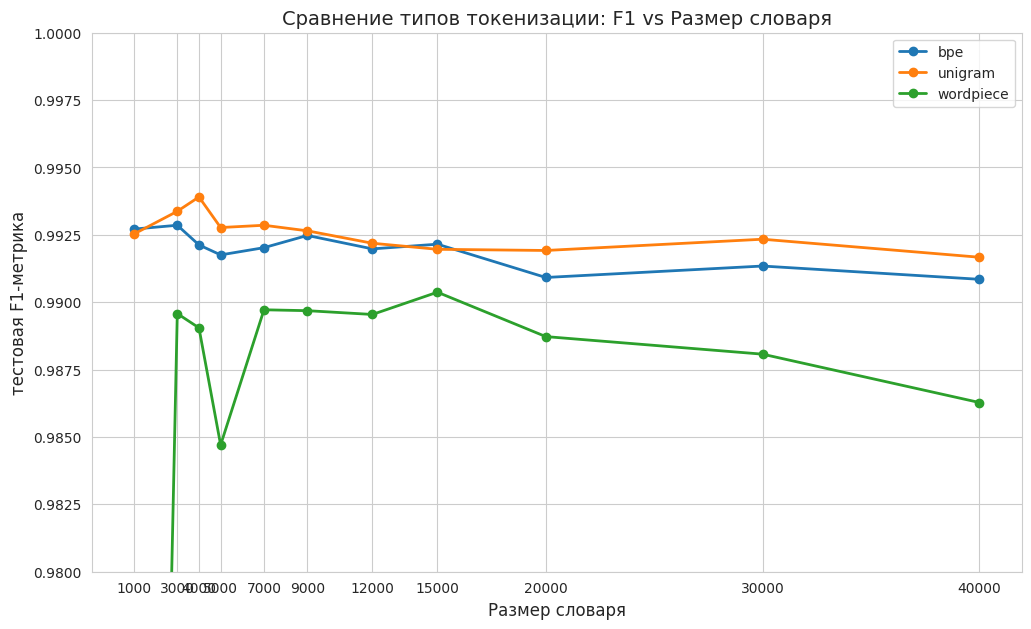

In [15]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

for t_type, scores in all_results.items():
    plt.plot(vocab_sizes, scores, marker='o', label=t_type, linewidth=2)

plt.title('Сравнение типов токенизации: F1 vs Размер словаря', fontsize=14)
plt.xlabel('Размер словаря', fontsize=12)
plt.ylabel('тестовая F1-метрика', fontsize=12)
plt.ylim((0.98, 1))
plt.legend()
plt.xticks(vocab_sizes)
plt.show()

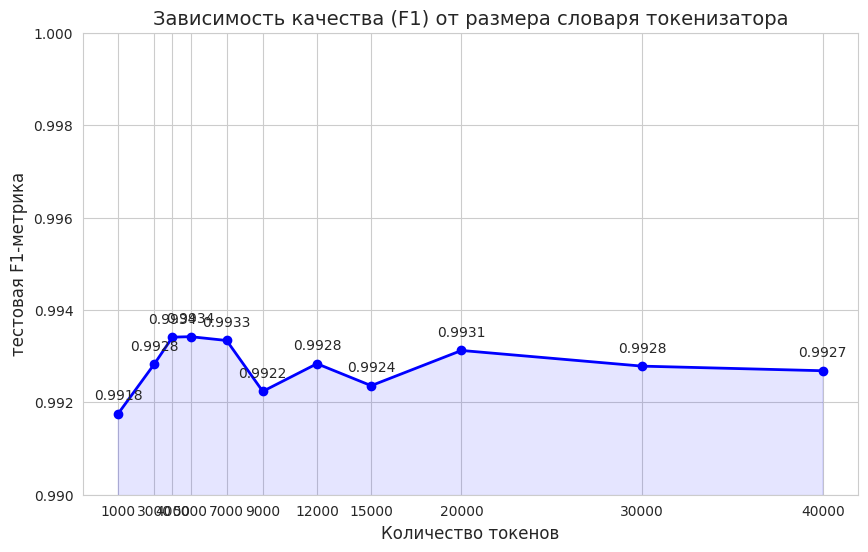

## выводы

- при увеличении словаря f1-мера сначала растет очень быстро, но после определенного порога (5-7к токенов) рост замедляется;
- слишком маленький словарь (1к токенов) заставляет токенизатор разбивать обычные слова на мелкие бессмысленные кусочки, что мешает модели улавливать контекст;
- слишком большой словарь (30-40к токенов) снижает качество, тк многие токены встречаются в датасете редко, и их эмбеддинги не успевают качественно обучиться;
- оптимальным для русского языка и твиттер-корпуса оказался размер в 5к токенов - лучшая точность;
- лучшим токенизатором оказался Unigram, вероятно, потому что его вероятностный подход к сегментации лучше адаптируется к сложной морфологии и шуму в коротких сообщениях, чем BPE и нестабильный WordPiece.